이미지 폴더: /home/jovyan/work/camera_sticker/images
폴더 안 파일들:
['king.png', 'hero.png', 'cat-whiskers.png', '.ipynb_checkpoints', 'my_image.png']
읽는 파일: /home/jovyan/work/camera_sticker/images/my_image.png
파일 존재: True
이미지 로드 결과: True
이미지 크기: (832, 555, 3)


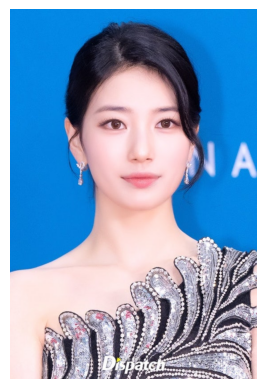

In [1]:
# 파일 및 폴더 경로를 다루기 위한 os 라이브러리
import os

# 이미지 처리(OpenCV)
import cv2

# 이미지 출력(Matplotlib)
import matplotlib.pyplot as plt


# 현재 사용자 홈 디렉토리 경로 가져오기
home_dir = os.getenv('HOME')

# 스티커 이미지들이 저장된 폴더 경로 생성
img_dir = os.path.join(home_dir, 'work/camera_sticker/images')

# 이미지 폴더 위치 확인
print("이미지 폴더:", img_dir)

# 이미지 폴더 안에 어떤 파일들이 있는지 확인
print("폴더 안 파일들:")
print(os.listdir(img_dir))

# 사용할 이미지(my_image.png)의 전체 경로 생성
my_image_path = os.path.join(img_dir, 'my_image.png')

# 읽어올 이미지 경로 출력
print("읽는 파일:", my_image_path)

# 해당 파일이 실제 존재하는지 확인
print("파일 존재:", os.path.exists(my_image_path))

# OpenCV로 이미지 읽기 (BGR 형식으로 불러옴)
img_bgr = cv2.imread(my_image_path)

# 이미지가 정상적으로 로드되었는지 확인
print("이미지 로드 결과:", img_bgr is not None)

# 이미지가 정상적으로 로드되었을 경우
if img_bgr is not None:

    # 이미지 크기 출력
    # (높이, 너비, 채널 수)
    print("이미지 크기:", img_bgr.shape)

    # OpenCV는 BGR 형식으로 이미지를 읽기 때문에
    # Matplotlib에서 정상 색상으로 출력하기 위해 RGB로 변환
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 이미지 출력
    plt.imshow(img_rgb)

    # 축 눈금 제거
    plt.axis('off')

    # 화면에 이미지 표시
    plt.show()

In [2]:
my_image_path = os.path.join(home_dir, 'work/camera_sticker/images/my_image.png')

In [3]:
# 필요한 패키지 import 하기
import os # 환경 변수나 디렉터리, 파일 등의 OS 자원을 제어할 수 있게 해주는 모듈
import cv2 # OpenCV라이브러리 → 컴퓨터 비전 관련 프로그래밍을 쉽게 할 수 있도록 도와주는 라이브러리
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np # 다차원 배열을 쉽게 처리하고 효율적으로 사용할 수 있도록 하는 라이브러리
import dlib # 이미지 처리 및 기계 학습, 얼굴인식 등을 할 수 있는 c++ 로 개발된 고성능의 라이브러리
print("🌫🛸")

🌫🛸


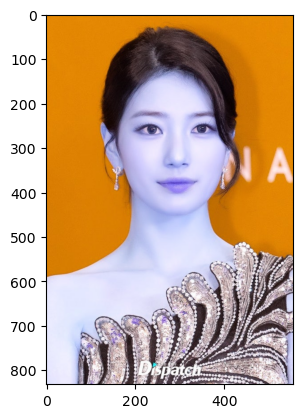

In [4]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/camera_sticker/images/my_image.png') 
img_bgr = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러옵니다
img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관합니다
plt.imshow(img_bgr) # 이미지를 출력하기 위해 출력할 이미지를 올려준다. (실제 출력은 하지 않음)
plt.show() # 이미지를 출력해준다. (실제 출력)

In [5]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
print("🌫🛸")

🌫🛸


In [6]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)
print("🌫🛸")

🌫🛸


rectangles[[(167, 192) (390, 415)]]


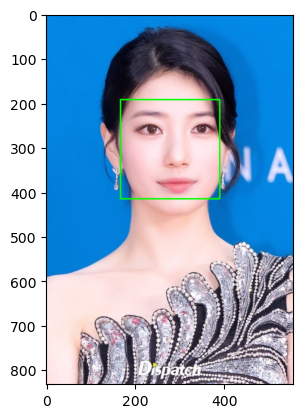

In [7]:
# 찾은 얼굴 영역 박스 리스트
# 여러 얼굴이 있을 수 있습니다
print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

In [8]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/camera_sticker/models
!cd ~/work/camera_sticker && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

--2026-06-22 06:48:11--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-06-22 06:48:11--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  14.4MB/s    in 5.3s    

2026-06-22 06:48:18 (11.6 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bzip2: Output file ./models/shape_predictor_68_face_landmarks.dat already exists.


In [9]:
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
    # 저장한 landmark 모델의 주소를 model_path 변수에 저장
landmark_predictor = dlib.shape_predictor(model_path)
    # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
    # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
    # dlib.rectangle: 내부를 예측하는 박스
    # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄
print("🌫🛸")

🌫🛸


In [10]:
list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

print(len(list_landmarks[0]))
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

68


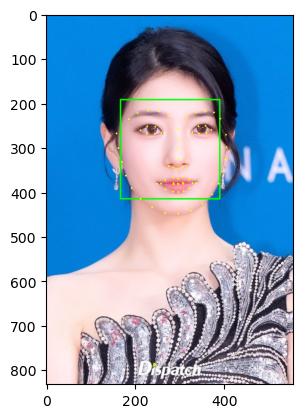

In [11]:
# list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)
            # cv2.circle: OpenCV의 원을 그리는 함수
            # img_show 이미지 위 각각의 point에
            # 크기가 2이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
            # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    # RGB 이미지로 전환
plt.imshow(img_show_rgb)
    # 이미지를 준비
plt.show()
    # 이미지를 출력

In [12]:
# zip() : 두 그룹의 데이터를 서로 엮어주는 파이썬의 내장 함수
# dlib_rects와 list_landmarks 데이터를 엮어 주었음
# dlib_rects : dlib이 검출한 얼굴 영역 정보를 저장하는 객체
# 각 얼굴의 left, top, right, bottom 좌표를 포함한다.
# list_landmarks : 얼굴의 68개 랜드마크 좌표(x,y)를 저장한 리스트

for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    print(landmark[30])  # 코 중심점 좌표

    # 코 중심점의 x좌표
    x = landmark[30][0]

    # 코 중심점의 y좌표에서 얼굴 높이의 절반만큼 위로 이동
    # 즉, 왕관이 얼굴 위쪽에 오도록 y 위치를 정함
    y = landmark[30][1] - dlib_rect.height() // 2

    # 얼굴 검출 영역의 가로 길이를 기준으로 왕관의 크기를 결정
    # 원래는 얼굴 폭과 동일한 크기였으나,
    # 0.55를 곱해 크기를 55%로 줄여 자연스럽게 보이도록 함
    w = h = int(dlib_rect.width() * 0.55)

    print(f'(x,y) : ({x},{y})')
    print(f'(w,h) : ({w},{h})')

(297, 324)
(x,y) : (297,212)
(w,h) : (123,123)


In [13]:
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/king.png')  # 왕관 스티커 이미지 경로

img_sticker = cv2.imread(sticker_path) # 왕관 스티커 이미지 불러오기

img_sticker = cv2.resize(img_sticker, (w, h)) # 얼굴 박스의 가로 길이에 맞춰 왕관 이미지를 w x h 크기로 조정

print(img_sticker.shape) # 조정된 왕관 이미지의 크기 확인

(123, 123, 3)


In [14]:
# x, y, w, h 는 위에서 계산한 왕관 위치 및 크기 정보
# refined_x
# 스티커의 기준점을 중앙에서 좌측 상단(top-left) 기준으로 변경
# 왕관 가로 길이의 절반만큼 왼쪽으로 이동

# 왕관이 얼굴 중앙보다 약간 왼쪽에 오도록 조정
# 10픽셀 왼쪽으로 이동
refined_x = x - w // 2 - 10

# 왕관의 기준 좌표를 얼굴 위쪽으로 이동
# h : 왕관 높이만큼 위로 이동
# 85 : 추가 여백을 주어 머리 위에 자연스럽게 위치하도록 조정
refined_y = y - h - 85

print(f'(x,y) : ({refined_x},{refined_y})')

# OpenCV는 이미지의 시작 좌표를 좌측 상단(top-left)으로 사용
# 따라서 얼굴 중심 좌표를 그대로 사용하면 왕관 위치가 맞지 않음
# 스티커의 좌측 상단 좌표로 변환해야 함

# refined_y가 음수이면 왕관 이미지의 일부가 원본 이미지 밖으로 벗어난 상태
# 이후 스티커를 잘라내는(cropping) 작업이 필요함

(x,y) : (226,4)


In [15]:
# 왕관 이미지가 이미지 밖에서 시작하지 않도록 조정이 필요함
# 좌표 순서가 y,x임에 유의한다. (y,x,rgb channel)
# 현재 상황에서는 -y 크기만큼 스티커를 crop 하고, top 의 x좌표와 y 좌표를 각각의 경우에 맞춰 원본 이미지의 경계 값으로 수정하면 아래와 같은 형식으로 나옵니다.
# 음수값 만큼 왕관 이미지(혹은 추후 적용할 스티커 이미지)를 자른다.
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0
# 왕관 이미지가 원본 이미지 위쪽 경계를 벗어나는 경우 이미지 밖에 위치한 부분을 잘라내고 y좌표를 0으로 보정

if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :]

    # refined_y가 음수이면 그만큼 왕관 이미지의 윗부분을 잘라낸다.

    refined_y = 0

print (f'(x,y) : ({refined_x},{refined_y})')

(x,y) : (226,4)


In [16]:
# sticker_area는 원본 이미지에서 스티커를 붙일 위치만 잘라낸 영역입니다.
# 현재 계산된 refined_x, refined_y 좌표를 기준으로 스티커 영역을 자른다.
# 좌표 순서는 이미지 배열 기준으로 [y좌표, x좌표] 입니다.

# img_show[refined_y:refined_y+img_sticker.shape[0],refined_x:refined_x+img_sticker.shape[1]]

# 즉, y좌표: 0 ~ 0 + img_sticker.shape[0] x좌표: 185 ~ 185 + img_sticker.shape[1]

sticker_area = img_show[refined_y:refined_y + img_sticker.shape[0],refined_x:refined_x + img_sticker.shape[1]]

# np.where는 조건에 따라 값을 선택하는 함수입니다.
# img_sticker == 0 인 부분은 스티커의 배경 부분이므로 원본 이미지(sticker_area)를 그대로 사용합니다.
# img_sticker != 0 인 부분은 왕관 그림이 있는 부분이므로 왕관 이미지(img_sticker)를 사용합니다.

img_show[refined_y:refined_y + img_sticker.shape[0],refined_x:refined_x + img_sticker.shape[1]] = np.where(img_sticker == 0,sticker_area,img_sticker).astype(np.uint8)

print("슝~")

슝~


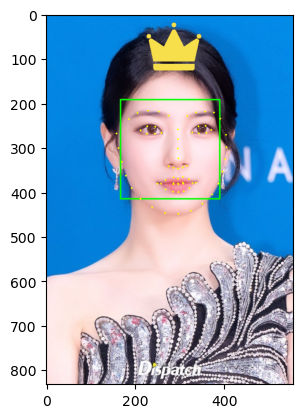

In [17]:
# 왕관 이미지를 적용한 이미지를 보여준다.
# 얼굴 영역(7-3)과 랜드마크(7-4)를 미리 적용해놓은 img_show에 왕관 이미지를 덧붙인 이미지가 나오게 된다.)
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

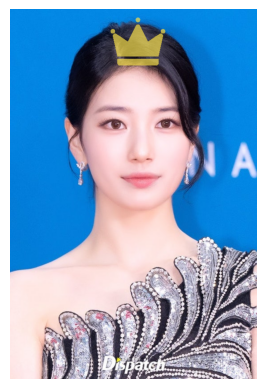

In [18]:
# addWeighted 실험용 이미지 따로 만들기
img_blend = cv2.imread(my_image_path)

# 스티커 영역 자르기
sticker_area = img_blend[
    refined_y:refined_y + img_sticker.shape[0],refined_x:refined_x + img_sticker.shape[1]]

# 검은 배경이 아닌 왕관 부분만 선택
mask = np.any(img_sticker > 10, axis=2)

# 반투명 합성
blended = cv2.addWeighted(sticker_area, 0.3,img_sticker, 0.7,0)

# 왕관 부분만 반투명 합성 적용
sticker_area[mask] = blended[mask]

# 다시 넣기
img_blend[
    refined_y:refined_y + img_sticker.shape[0],refined_x:refined_x + img_sticker.shape[1]] = sticker_area

# 결과 출력
plt.imshow(cv2.cvtColor(img_blend, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

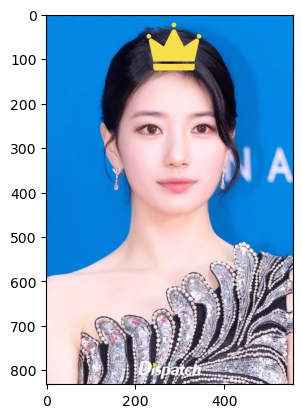

In [19]:
# 위에서 설명했으므로 생략
# 왕관 이미지
sticker_area = img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# img_bgr은 OpenCV로 불러온 BGR 형식의 원본 이미지이다.
img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==0,sticker_area,img_sticker).astype(np.uint8)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)) # rgb만 적용해놓은 원본 이미지에 왕관 이미지를 덮어 씌운 이미지가 나오게 된다.
plt.show()

In [20]:
# 고양이 수염 이미지 경로 설정
sticker_path = '/home/jovyan/work/camera_sticker/images/cat-whiskers.png'

# OpenCV를 이용하여 수염 이미지 불러오기
img_sticker = cv2.imread(sticker_path)

# 수염 이미지 크기 확인
print(img_sticker.shape)

(512, 512, 3)


In [21]:
# 얼굴 영역(dlib_rect)과 랜드마크(68개 점)를 하나씩 꺼내옴
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):

    # 랜드마크 30번은 코 중심 부근의 위치
    # 수염은 코를 중심으로 배치할 것이므로 기준점으로 사용
    x = landmark[30][0]
    y = landmark[30][1]
    

    print(f"코 위치 : ({x}, {y})")

코 위치 : (297, 324)


In [22]:
# 수염 크기를 얼굴 폭의 70%로 줄이기
# 얼굴 크기에 따라 수염 크기도 자동 조절됨
w = int(dlib_rect.width() * 0.70)

# 원본 수염 이미지의 높이와 너비 저장
sticker_h, sticker_w = img_sticker.shape[:2]

# 원본 비율을 유지하면서 높이 계산
h = int(sticker_h * w / sticker_w)

# 계산된 크기로 수염 이미지 크기 조정
img_sticker = cv2.resize(img_sticker, (w, h))

# 조정된 수염 이미지 크기 확인
print(img_sticker.shape)

(156, 156, 3)


In [23]:
# 코 위치를 기준으로 수염의 중심을 맞춤

# 수염 가로 길이의 절반만큼 왼쪽으로 이동
# 수염 중심이 코 중심과 일치하도록 함
refined_x = x - w // 2

# 수염 세로 길이의 절반만큼 위로 이동
# 이후 +5을 하여 수염이 코 바로 아래에 오도록 조정
refined_y = y - h // 2 + 5

print(f"(x,y) : ({refined_x}, {refined_y})")

(x,y) : (219, 251)


In [24]:
# 수염이 이미지 왼쪽 밖으로 나간 경우
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0

# 수염이 이미지 위쪽 밖으로 나간 경우
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :]
    refined_y = 0

In [25]:
# 원본 이미지에서 수염이 들어갈 영역 잘라내기
sticker_area = img_show[
    refined_y:refined_y + img_sticker.shape[0],refined_x:refined_x + img_sticker.shape[1]]

# 흰색 배경 찾기
mask = np.all(img_sticker > 240, axis=2)

# 흰색은 원본 유지
# 검은 수염 부분만 덮어쓰기
sticker_area[~mask] = img_sticker[~mask]

# 원본 이미지에 다시 붙이기
img_show[
    refined_y:refined_y + img_sticker.shape[0],refined_x:refined_x + img_sticker.shape[1]] = sticker_area

print("고양이 수염 적용 완료 😺")

고양이 수염 적용 완료 😺


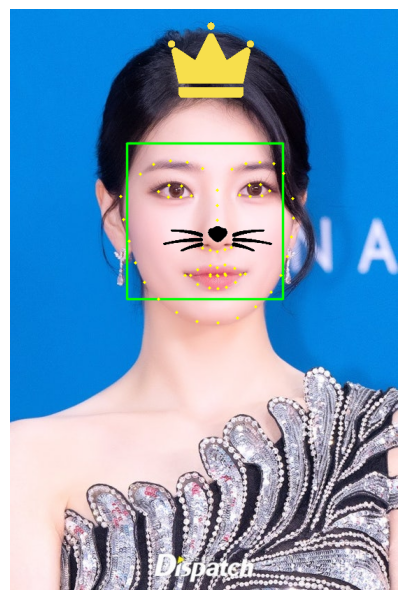

In [26]:
# 수염이 적용된 최종 이미지를 화면에 출력
# OpenCV는 BGR 형식이므로 matplotlib에서 보기 위해 RGB로 변환

img_final = img_show.copy()

# 최종 결과 출력
plt.figure(figsize=(5,8))
plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

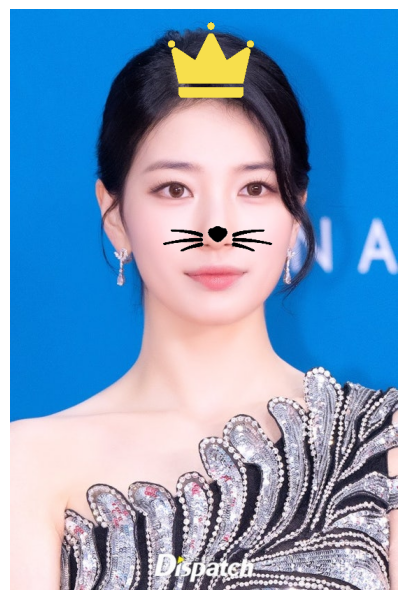

In [27]:
# 최종 이미지
img_final = img_bgr.copy()

# 수염 이미지 불러오기
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/cat-whiskers.png')
img_sticker = cv2.imread(sticker_path)

# 코 위치 기준
x = landmark[30][0]
y = landmark[30][1]

# 수염 크기 조정
w = int(dlib_rect.width() * 0.70)
sticker_h, sticker_w = img_sticker.shape[:2]
h = int(sticker_h * w / sticker_w)
img_sticker = cv2.resize(img_sticker, (w, h))

# 수염 위치
refined_x = x - w // 2
refined_y = y - h // 2 + 5 

# 수염 붙이기
sticker_area = img_final[
    refined_y:refined_y + img_sticker.shape[0],refined_x:refined_x + img_sticker.shape[1]]

mask = np.all(img_sticker > 240, axis=2)
sticker_area[~mask] = img_sticker[~mask]

img_final[
    refined_y:refined_y + img_sticker.shape[0],refined_x:refined_x + img_sticker.shape[1]] = sticker_area

# 최종 출력
plt.figure(figsize=(5,8))
plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# 디버깅

1. 이미지 파일이 변경되지 않는 문제

초기에는 my_image.png를 다른 사진으로 교체했음에도 불구하고 기존 이미지가 계속 출력되는 문제가 발생하였다. 원인을 확인한 결과, 노트북 상단의 wget 코드가 실행되면서 매번 기본 이미지가 다시 다운로드되어 my_image.png를 덮어쓰고 있었다. 해당 셀을 실행하지 않도록 하거나 직접 업로드한 이미지를 다시 저장하여 문제를 해결하였다.

2. 왕관 크기 및 위치 조정

왕관 스티커를 처음 적용했을 때 크기가 지나치게 크게 출력되어 얼굴을 가리거나 이미지 경계를 벗어나는 문제가 발생하였다. 또한 왕관이 머리 위가 아닌 얼굴에 너무 가깝게 배치되어 부자연스럽게 보였다. 이를 해결하기 위해 얼굴 영역의 너비를 기준으로 왕관 크기를 비율로 조정하였으며, y좌표 값을 반복적으로 수정하면서 가장 자연스럽게 보이는 위치를 찾았다. 여러 번의 실험 결과 왕관의 크기와 위치를 적절히 조정하여 얼굴 위에 자연스럽게 배치할 수 있었고, 스티커의 크기와 위치를 얼굴 크기에 맞게 조절하는 과정이 중요하다는 점을 확인할 수 있었다.

3. 랜드마크 좌표 오류

수염 스티커를 부착하는 과정에서 랜드마크 번호 선택에 따라 수염 위치가 부자연스럽게 출력되었다. 처음에는 코 끝 좌표를 사용하였으나 수염이 얼굴 중심에서 벗어나거나 코에 너무 가깝게 붙는 문제가 발생하였다. 여러 랜드마크 위치를 비교한 결과 현재 위치가 가장 자연스럽게 보인다고 판단하여 최종 위치를 선정하였다.

4. 수염 이미지 배경 문제

고양이 수염 이미지를 적용할 때 흰색 배경까지 함께 출력되는 문제가 발생하였다. 원인을 분석한 결과 PNG 파일의 배경을 제거하지 않고 그대로 합성했기 때문이었다. 이후 마스크(mask)를 활용하여 수염 부분만 합성하도록 수정하였다.

5. addWeighted 적용 시 검은 배경 발생

cv2.addWeighted()를 사용하여 스티커를 반투명하게 합성하는 과정에서 왕관 주변이 검게 출력되는 문제가 발생하였다. 이는 스티커 이미지의 검은 배경까지 함께 합성되었기 때문이었다. 마스크를 적용하여 왕관 부분만 합성하도록 수정하였으며, 원본 이미지와 스티커 이미지를 별도 변수로 관리하여 원본이 손상되지 않도록 하였다.

# 얼굴 각도, 밝기, 촬영거리 분석 등의 영향과 문제점 분석

1. 얼굴 각도에 따른 영향

현재 구현한 스티커는 얼굴이 정면을 향하고 있을 때 가장 자연스럽게 적용된다. 내가 적용한 사진은 정면 사진이므로 얼굴 랜드마크가 정확하게 검출되어 왕관과 수염의 위치를 안정적으로 계산할 수 있었다.
하지만 얼굴을 좌우로 돌리거나 고개를 기울이면 왕관과 수염의 위치가 부자연스럽게 배치될 수 있다. 특히 왕관은 얼굴의 회전 각도를 고려하지 않고 단순히 좌표만 계산하기 때문에 얼굴이 기울어져도 왕관은 수평 상태를 유지한다. 실제 카메라 필터처럼 자연스럽게 만들기 위해서는 얼굴의 기울기 각도를 계산하여 스티커도 함께 회전하도록 구현할 필요가 있다.

2. 이미지 밝기에 따른 영향

이미지가 충분히 밝은 경우 얼굴 검출과 랜드마크 검출이 안정적으로 수행되었다. 반면 이미지가 지나치게 어두운 경우 얼굴 윤곽과 이목구비 특징을 찾기 어려워 검출 정확도가 감소할 수 있다.

3. 촬영 거리에 따른 영향

얼굴이 적절한 크기로 촬영된 경우 랜드마크를 정확하게 검출할 수 있었다. 얼굴이 너무 멀리 있는 경우 얼굴 영역이 작아져 랜드마크 검출 정확도가 떨어질 수 있으며, 반대로 너무 가까운 경우 일부 얼굴 영역이 잘려 검출에 영향을 줄 수 있다.

4. 옆모습 촬영 시 문제점

현재 사용한 dlib 랜드마크 모델은 정면 또는 반측면 얼굴에 최적화되어 있다. 얼굴이 옆으로 많이 돌아간 경우 일부 랜드마크가 정확하게 검출되지 않을 수 있으며, 그 결과 수염이나 왕관의 위치가 잘못 계산될 수 있다.

5. 실행 속도 문제

정지 이미지에서는 큰 문제가 없지만 실시간 카메라 영상에 적용할 경우 얼굴 검출과 랜드마크 추출을 매 프레임마다 수행해야 한다. 얼굴 수가 많아지거나 이미지 해상도가 높아질수록 처리 속도가 느려질 수 있으므로 최적화가 필요하다.

6. 스티커 위치 정확도의 중요성

스티커 위치가 몇 픽셀만 어긋나도 사용자가 부자연스럽게 느낄 수 있다. 실제로 이번 프로젝트에서도 랜드마크 번호 선택에 따라 수염의 위치가 크게 달라졌다. 따라서 스티커 기능에서는 얼굴 특징점을 정확하게 검출하는 것이 매우 중요하며, 다양한 랜드마크를 비교하여 가장 자연스러운 위치를 찾는 과정이 필요하다.

6. 다양한 얼굴 조건에 대한 한계

안경, 마스크, 머리카락, 강한 조명, 그림자 등의 환경에서는 랜드마크 검출 정확도가 낮아질 수 있다. 또한 사람마다 얼굴형과 이목구비 비율이 다르기 때문에 동일한 스티커 크기와 위치를 적용하더라도 결과가 다르게 보일 수 있다.

# 회고

이번 프로젝트를 통해 OpenCV와 dlib을 활용한 얼굴 검출 및 랜드마크 추출 과정을 직접 경험할 수 있었다. 특히 얼굴의 특정 위치를 좌표로 표현하고 이를 이용하여 스티커를 자연스럽게 배치하는 과정이 흥미로웠다.

프로젝트를 진행하면서 이미지 경로 설정, 파일 불러오기, 랜드마크 좌표 계산, 이미지 합성 등 다양한 오류를 경험하였다. 처음에는 오류 메시지의 의미를 이해하기 어려웠지만, 경로를 확인하고 변수의 값을 출력해 보면서 원인을 하나씩 찾는 디버깅 과정을 통해 문제 해결 능력을 향상시킬 수 있었다.

또한 동일한 스티커라도 랜드마크 선택과 위치 조정에 따라 결과가 크게 달라진다는 점을 확인할 수 있었다. 왕관 스티커는 크기와 위치에 따라 결과가 크게 달라졌으며, 여러 차례 좌표와 크기를 수정하면서 최적의 값을 찾았다. 이를 통해 얼굴 랜드마크를 활용한 스티커 기능에서는 정확한 위치 계산뿐만 아니라 스티커 크기 조정 역시 매우 중요하다는 것을 배울 수 있었다. 또한, 고양이 수염의 경우 여러 랜드마크를 비교하면서 가장 자연스러운 위치를 찾기 위해 반복적으로 실험하였고, 이를 통해 컴퓨터 비전에서는 단순히 검출 결과를 사용하는 것뿐만 아니라, 사용 목적에 맞게 후처리하는 과정이 매우 중요하다는 것을 알게 되었다.

이번 프로젝트를 통해 얼굴 검출, 랜드마크 검출, 이미지 합성의 전체 흐름을 이해할 수 있었으며, 앞으로는 다양한 스티커와 얼굴 각도에 대응할 수 있는 보다 정교한 필터를 구현해 보고 싶다.